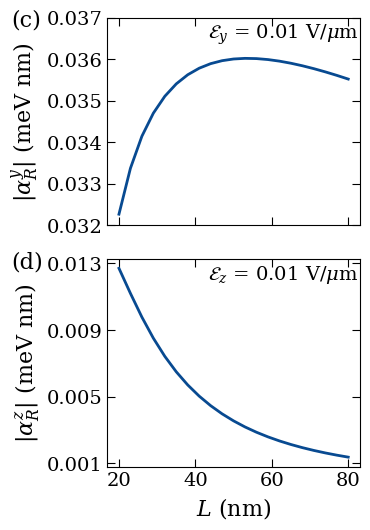

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# ======= PLOT SETTINGS =======
plt.rcParams.update({
    "figure.figsize": [4, 5.4],
    "font.family": "Serif",
    "mathtext.fontset": "dejavuserif",
    "axes.linewidth": 0.8
})

cmap_blue = plt.cm.Blues
cmap_red = plt.cm.Reds
blue_colors = cmap_blue([0.5, 0.7, 0.9])
red_colors  = cmap_red([0.5, 0.7, 0.9])

# ==================================================
# Parameters for the two calculations
# ==================================================
# Y-direction data
N_y = 100
kx_y = 0.0005
Ef_y = 0.1e-5

# Z-direction data
N_z = 100
kx_z = 0.0005
Ef_z = 0.1e-5

# ==================================================
# Load data
# ==================================================
filename_y = f"Pymablock_Y_kx{kx_y}_E_{(Ef_y*10000):.3f}_N{N_y}.dat"
filename_z = f"Pymablock_Z_kx{kx_z}_E_{(Ef_z*10000):.3f}_N{N_z}.dat"

data_y = np.loadtxt(filename_y, comments="#")
data_z = np.loadtxt(filename_z, comments="#")

L_y_nm = data_y[:, 0]
alpha_y_eVA = data_y[:, 1]

L_z_nm = data_z[:, 0]
alpha_z_eVA = data_z[:, 1]

# ==================================================
# Convert alpha: eV Angstrom -> meV nm
# 1 eV Angstrom = 100 meV nm
# ==================================================
alpha_y_meV_nm = np.abs(alpha_y_eVA * 100.0)
alpha_z_meV_nm = np.abs(alpha_z_eVA * 100.0)

# ======= CREATE 1x2 GRID =======
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)

# --- Left Plot: Y Direction ---
ax1.plot(
    L_y_nm,
    alpha_y_meV_nm,
    '-',
    color=blue_colors[2],
    label=r"$\alpha_y$",
    linewidth=2,
    # markersize=5,
    # markerfacecolor='None'
)
ax1.set_ylabel(r"$|\alpha_R^y|$ (meV nm)", fontsize=16)

# --- Right Plot: Z Direction ---
ax2.plot(
    L_z_nm,
    alpha_z_meV_nm,
    '-',
    color=blue_colors[2],
    label=r"$\alpha_z$",
    linewidth=2,
    # markersize=5,
    # markerfacecolor='None'
)
ax2.set_ylabel(r"$|\alpha_R^z|$ (meV nm)", fontsize=16)

# --- Common Formatting ---
for ax in [ax1, ax2]:
    
    ax.tick_params(direction='in', length=6, width=0.8,
                   top=True, right=True, labelsize=14)
    ax.set_xticks([20, 40, 60, 80])
ax2.set_xlabel(r"$L$ (nm)", fontsize=16)
# Optional fixed y-ticks, adjust/remove depending on your data range
ax1.set_yticks([0.032, 0.033, 0.034, 0.035, 0.036, 0.037])
ax2.set_yticks([0.001, 0.005, 0.009, 0.013])

# --- Text annotations ---
ax1.text(0.4, 0.90,
         r"$\mathcal{E}_y$ = " + f"{Ef_y*10000:.2f}" + r" V/$\mu$m",
         transform=ax1.transAxes, fontsize=14)
# ax1.text(0.4, 0.80,
#          r"$k_x$ = " + f"{kx_y}" + r" $\AA^{-1}$",
#          transform=ax1.transAxes, fontsize=14)

ax2.text(0.4, 0.90,
         r"$\mathcal{E}_z$ = " + f"{Ef_z*10000:.2f}" + r" V/$\mu$m",
         transform=ax2.transAxes, fontsize=14)
# ax2.text(0.4, 0.80,
#          r"$k_x$ = " + f"{kx_z}" + r" $\AA^{-1}$",
#          transform=ax2.transAxes, fontsize=14)

# --- Panel labels (a), (b) ---
ax1.text(-0.38, 1.04, "(c)", transform=ax1.transAxes,
         fontsize=16, va='top')
ax2.text(-0.38, 1.04, "(d)", transform=ax2.transAxes,
         fontsize=16, va='top')

# --- Layout ---
plt.tight_layout()
plt.subplots_adjust(wspace=0.4)

# Save
plt.savefig(f"alpha_vs_L_YZ_Ny{N_y}_Nz{N_z}.png", dpi=300)
plt.savefig(f"alpha_vs_L_YZ_Ny{N_y}_Nz{N_z}.pdf", dpi=300)
plt.show()
